In [1]:
!pip install -q kagglehub

In [2]:
# 2. Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import kagglehub


In [3]:
# 3. Descarga del dataset desde Kaggle con kagglehub
# kagglehub descarga el dataset sin pasos manuales y hace el notebook reproducible.

path = kagglehub.dataset_download('mikoajkolman/pokemon-images-first-generation17000-files')

# Carpeta raiz que contiene las subcarpetas (una por Pokemon)
DATA_DIR = None
for root, dirs, files in os.walk(path):
    if len(dirs) > 100:
        DATA_DIR = root
        break


100%|██████████| 2.81G/2.81G [02:44<00:00, 18.4MB/s]

Extracting files...


Clases: 143 | Imagenes: 16482 | Promedio por clase: 115 (min 45, max 214)


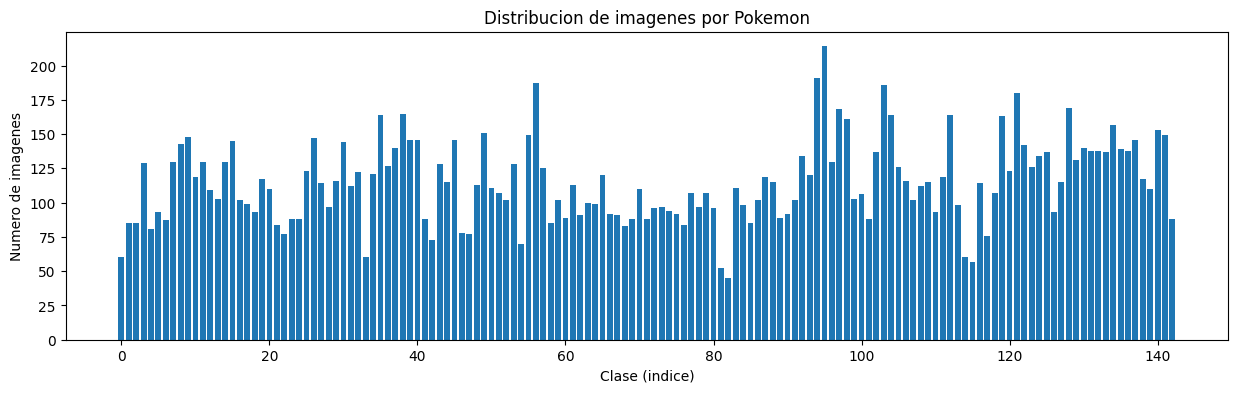

In [4]:
# 4. Exploracion del dataset: numero de imagenes por clase
class_names = sorted(os.listdir(DATA_DIR))
counts = {}
for c in class_names:
    folder = os.path.join(DATA_DIR, c)
    if os.path.isdir(folder):
        counts[c] = len([f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f'Clases: {len(counts)} | Imagenes: {sum(counts.values())} | '
      f'Promedio por clase: {sum(counts.values()) / len(counts):.0f} '
      f'(min {min(counts.values())}, max {max(counts.values())})')

plt.figure(figsize=(15, 4))
plt.bar(range(len(counts)), list(counts.values()))
plt.xlabel('Clase (indice)')
plt.ylabel('Numero de imagenes')
plt.title('Distribucion de imagenes por Pokemon')
plt.show()


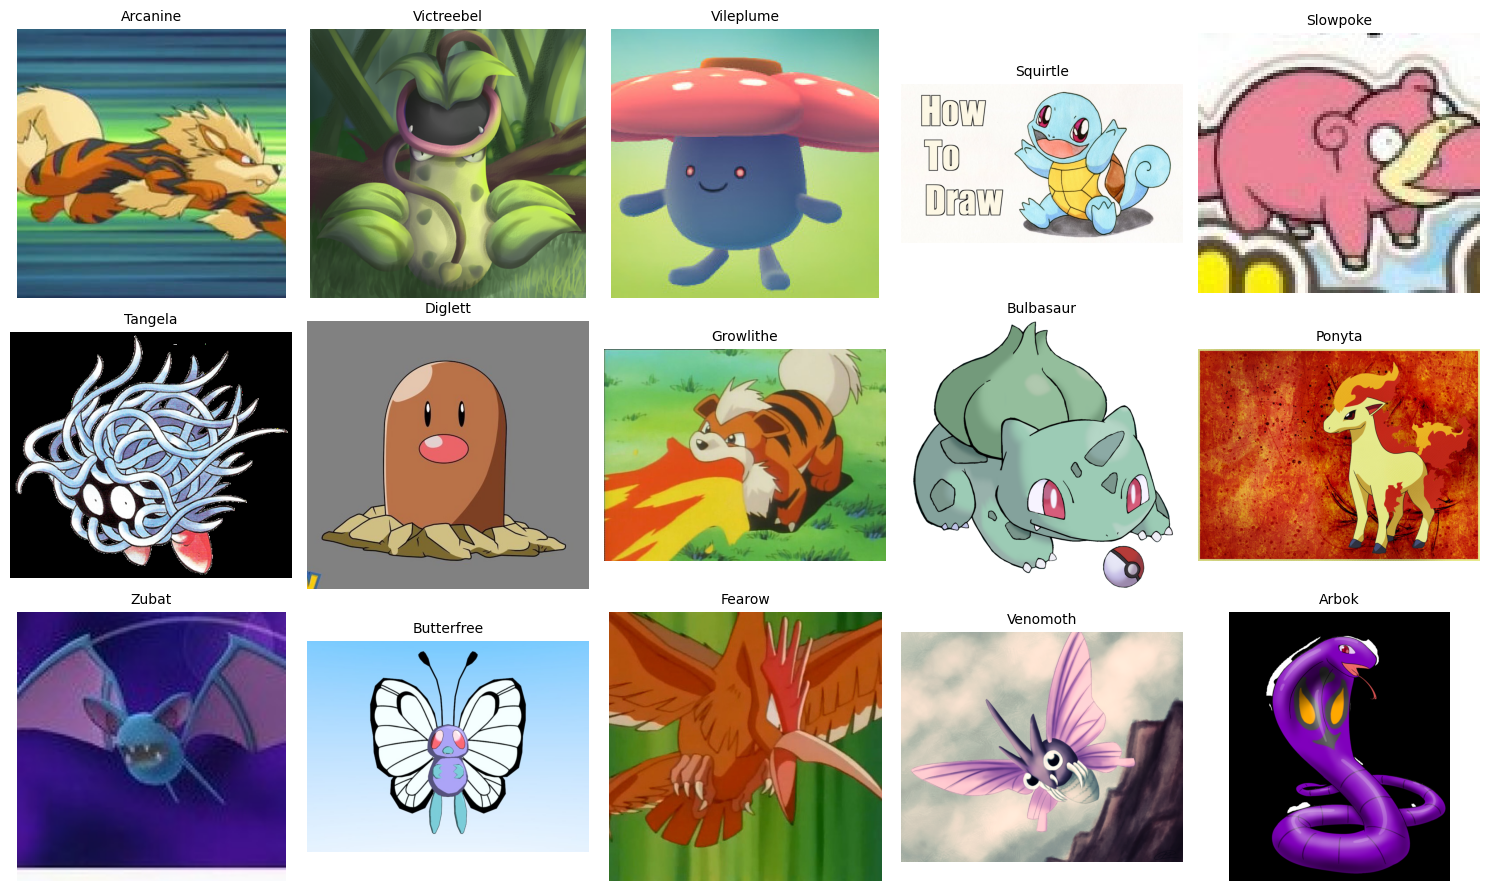

In [5]:
# 5. Visualizacion de imagenes de ejemplo
import random
from PIL import Image

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
sample_classes = random.sample(class_names, 15)
for ax, cls in zip(axes.flat, sample_classes):
    folder = os.path.join(DATA_DIR, cls)
    img_files = [f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    if img_files:
        img_path = os.path.join(folder, random.choice(img_files))
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.set_title(cls, fontsize=10)
        ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
# 6. Preparacion del dataset con ImageDataGenerator
# - Rescalado de pixeles a [0,1] (1./255)
# - Redimensionado a 128x128
# - Split 80/20 train/validation con validation_split
# - Data augmentation SOLO en entrenamiento

IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes


Found 13246 images belonging to 143 classes.
Found 3239 images belonging to 143 classes.


In [7]:
# 7. Construccion del modelo con Transfer Learning (MobileNetV2)
# Justificacion: MobileNetV2 preentrenada en ImageNet captura features visuales
# generales (bordes, texturas, formas) que se reutilizan para reconocer Pokemon.

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Congelamos la base para transfer learning puro

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 143)            │        36,751 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,622,671 (10.00 MB)

 Trainable params: 364,687 (1.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# 8. Callbacks: ModelCheckpoint, EarlyStopping y ReduceLROnPlateau
callbacks = [
    ModelCheckpoint(
        'pokemon_cnn_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

In [9]:
# 9. Entrenamiento del modelo (fase 1: transfer learning con base congelada)
EPOCHS = 15

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
 19/414 ━━━━━━━━━━━━━━━━━━━━ 2:02 309ms/step - accuracy: 0.0041 - loss: 5.6131

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.1049 - loss: 4.4356
Epoch 1: val_accuracy improved from None to 0.57425, saving model to pokemon_cnn_best.h5



Epoch 1: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 240s 523ms/step - accuracy: 0.2100 - loss: 3.6673 - val_accuracy: 0.5743 - val_loss: 1.8414 - learning_rate: 0.0010
Epoch 2/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.4650 - loss: 2.1867
Epoch 2: val_accuracy improved from 0.57425 to 0.70176, saving model to pokemon_cnn_best.h5



Epoch 2: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 186s 451ms/step - accuracy: 0.4810 - loss: 2.0955 - val_accuracy: 0.7018 - val_loss: 1.2387 - learning_rate: 0.0010
Epoch 3/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.5508 - loss: 1.7436
Epoch 3: val_accuracy improved from 0.70176 to 0.73202, saving model to pokemon_cnn_best.h5


...


Epoch 7: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 187s 453ms/step - accuracy: 0.6530 - loss: 1.2816 - val_accuracy: 0.7740 - val_loss: 0.8592 - learning_rate: 0.0010
Epoch 8/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6744 - loss: 1.2072
Epoch 8: val_accuracy improved from 0.77400 to 0.78141, saving model to pokemon_cnn_best.h5



Epoch 8: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 186s 450ms/step - accuracy: 0.6705 - loss: 1.2216 - val_accuracy: 0.7814 - val_loss: 0.8684 - learning_rate: 0.0010
Epoch 9/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6810 - loss: 1.1906
Epoch 9: val_accuracy did not improve from 0.78141

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
414/414 ━━━━━━━━━━━━━━━━━━━━ 190s 458ms/step - accuracy: 0.6768 - loss: 1.1937 - val_accuracy: 0.7725 - val_loss: 0.8768 - learning_rate: 0.0010
Epoch 10/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.7070 - loss: 1.0418
Epoch 10: val_accuracy improved from 0.78141 to 0.79191, saving model to pokemon_cnn_best.h5



Epoch 10: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 188s 454ms/step - accuracy: 0.7080 - loss: 1.0414 - val_accuracy: 0.7919 - val_loss: 0.7981 - learning_rate: 5.0000e-04
Epoch 11/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.7299 - loss: 0.9784
Epoch 11: val_accuracy did not improve from 0.79191
414/414 ━━━━━━━━━━━━━━━━━━━━ 189s 456ms/step - accuracy: 0.7225 - loss: 1.0101 - val_accuracy: 0.7882 - val_loss: 0.7935 - learning_rate: 5.0000e-04
Epoch 12/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.7251 - loss: 0.9837
Epoch 12: val_accuracy improved from 0.79191 to 0.80210, saving model to pokemon_cnn_best.h5



Epoch 12: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 183s 442ms/step - accuracy: 0.7263 - loss: 0.9739 - val_accuracy: 0.8021 - val_loss: 0.7808 - learning_rate: 5.0000e-04
Epoch 13/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.7263 - loss: 0.9750
Epoch 13: val_accuracy improved from 0.80210 to 0.80303, saving model to pokemon_cnn_best.h5



Epoch 13: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 186s 449ms/step - accuracy: 0.7271 - loss: 0.9839 - val_accuracy: 0.8030 - val_loss: 0.7514 - learning_rate: 5.0000e-04
Epoch 14/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.7422 - loss: 0.9062
Epoch 14: val_accuracy did not improve from 0.80303
414/414 ━━━━━━━━━━━━━━━━━━━━ 186s 449ms/step - accuracy: 0.7364 - loss: 0.9217 - val_accuracy: 0.7938 - val_loss: 0.7711 - learning_rate: 5.0000e-04
Epoch 15/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.7444 - loss: 0.8947
Epoch 15: val_accuracy did not improve from 0.80303

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
414/414 ━━━━━━━━━━━━━━━━━━━━ 186s 450ms/step - accuracy: 0.7418 - loss: 0.9100 - val_accuracy: 0.7984 - val_loss: 0.7730 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 13.


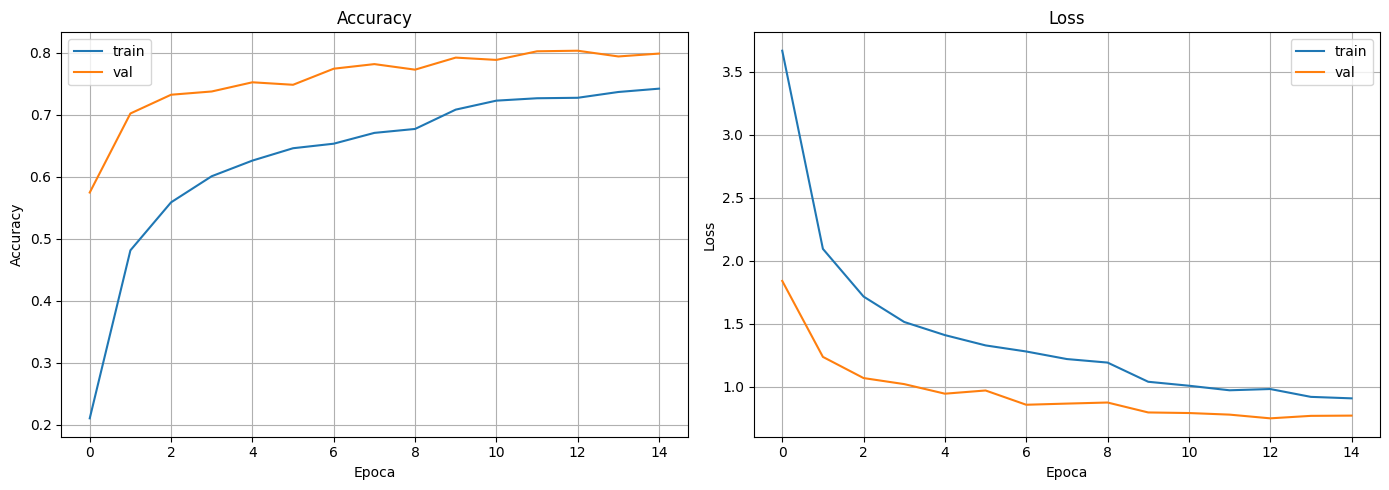

In [10]:
# 10. Graficas de loss y accuracy (entrenamiento vs validacion)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
# 11. Fine-tuning (fase 2): descongelamos las ultimas capas de MobileNetV2
# para ajustar mejor el modelo a Pokemon.
base_model.trainable = True
# Solo descongelamos las ultimas 30 capas
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # LR muy bajo para no destruir los pesos
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.4990 - loss: 2.0425
Epoch 1: val_accuracy did not improve from 0.80303
414/414 ━━━━━━━━━━━━━━━━━━━━ 227s 504ms/step - accuracy: 0.5289 - loss: 1.8733 - val_accuracy: 0.8015 - val_loss: 0.7302 - learning_rate: 1.0000e-05
Epoch 2/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.5967 - loss: 1.5233
Epoch 2: val_accuracy did not improve from 0.80303
414/414 ━━━━━━━━━━━━━━━━━━━━ 188s 454ms/step - accuracy: 0.6131 - loss: 1.4699 - val_accuracy: 0.8009 - val_loss: 0.7266 - learning_rate: 1.0000e-05
Epoch 3/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.6384 - loss: 1.3177
Epoch 3: val_accuracy improved from 0.80303 to 0.80426, saving model to pokemon_cnn_best.h5



Epoch 3: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 184s 444ms/step - accuracy: 0.6486 - loss: 1.2826 - val_accuracy: 0.8043 - val_loss: 0.7224 - learning_rate: 1.0000e-05
Epoch 4/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.6694 - loss: 1.2022
Epoch 4: val_accuracy improved from 0.80426 to 0.81136, saving model to pokemon_cnn_best.h5



Epoch 4: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 187s 450ms/step - accuracy: 0.6711 - loss: 1.1957 - val_accuracy: 0.8114 - val_loss: 0.7113 - learning_rate: 1.0000e-05
Epoch 5/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.6907 - loss: 1.1071
Epoch 5: val_accuracy did not improve from 0.81136
414/414 ━━━━━━━━━━━━━━━━━━━━ 187s 450ms/step - accuracy: 0.6997 - loss: 1.0873 - val_accuracy: 0.8107 - val_loss: 0.7043 - learning_rate: 1.0000e-05
Epoch 6/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.7172 - loss: 1.0385
Epoch 6: val_accuracy improved from 0.81136 to 0.81414, saving model to pokemon_cnn_best.h5



Epoch 6: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 187s 451ms/step - accuracy: 0.7161 - loss: 1.0405 - val_accuracy: 0.8141 - val_loss: 0.6883 - learning_rate: 1.0000e-05
Epoch 7/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.7179 - loss: 1.0062
Epoch 7: val_accuracy improved from 0.81414 to 0.82062, saving model to pokemon_cnn_best.h5



Epoch 7: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 185s 446ms/step - accuracy: 0.7213 - loss: 0.9993 - val_accuracy: 0.8206 - val_loss: 0.6702 - learning_rate: 1.0000e-05
Epoch 8/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.7361 - loss: 0.9537
Epoch 8: val_accuracy improved from 0.82062 to 0.82525, saving model to pokemon_cnn_best.h5



Epoch 8: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 186s 448ms/step - accuracy: 0.7371 - loss: 0.9359 - val_accuracy: 0.8253 - val_loss: 0.6572 - learning_rate: 1.0000e-05
Epoch 9/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.7452 - loss: 0.9048
Epoch 9: val_accuracy improved from 0.82525 to 0.82927, saving model to pokemon_cnn_best.h5



Epoch 9: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 186s 450ms/step - accuracy: 0.7506 - loss: 0.8892 - val_accuracy: 0.8293 - val_loss: 0.6420 - learning_rate: 1.0000e-05
Epoch 10/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.7568 - loss: 0.8581
Epoch 10: val_accuracy improved from 0.82927 to 0.83390, saving model to pokemon_cnn_best.h5



Epoch 10: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 230s 556ms/step - accuracy: 0.7544 - loss: 0.8650 - val_accuracy: 0.8339 - val_loss: 0.6303 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.


In [12]:
# 12. Evaluacion final con classification_report y matriz de confusion

val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

print('Accuracy global:', np.mean(y_pred == y_true))
print()
print('Classification report:')
print(classification_report(y_true, y_pred, target_names=class_labels, zero_division=0))

102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 443ms/step
Accuracy global: 0.8338993516517443

Classification report:
              precision    recall  f1-score   support

        Abra       0.78      0.58      0.67        12
  Aerodactyl       0.92      0.65      0.76        17
    Alakazam       0.81      0.76      0.79        17
       Arbok       0.86      0.96      0.91        25
    Arcanine       0.92      0.69      0.79        16
    Articuno       0.92      0.67      0.77        18
    Beedrill       1.00      0.88      0.94        17
  Bellsprout       0.96      0.92      0.94        26
   Blastoise       0.88      0.75      0.81        28
   Bulbasaur       0.94      1.00      0.97        29
  Butterfree       0.92      1.00      0.96        23
    Caterpie       0.84      1.00      0.91        26
     Chansey       0.84      0.76      0.80        21
   Charizard       0.84      0.80      0.82        20
  Charmander       0.70      1.00      0.83        26
  Charmeleon       0.74      0.

Shape de la matriz de confusion: (143, 143)

Top 10 Pokemon que mas se confunden:
  Pidgey: 15 errores de 38 muestras
  Primeape: 11 errores de 27 muestras
  Pidgeotto: 11 errores de 24 muestras
  Rhydon: 11 errores de 22 muestras
  Mankey: 11 errores de 18 muestras
  Machamp: 10 errores de 18 muestras
  Pinsir: 10 errores de 26 muestras
  Pidgeot: 9 errores de 26 muestras
  Kadabra: 9 errores de 17 muestras
  Electabuzz: 9 errores de 24 muestras

Top 15 confusiones (real -> predicho):
  Starmie        -> Staryu         8 veces
  Poliwhirl      -> Poliwrath      7 veces
  Pidgeotto      -> Pidgeot        6 veces
  Electrode      -> Voltorb        5 veces
  Mr. Mime       -> MrMime         5 veces
  Pidgeot        -> Pidgeotto      5 veces
  Blastoise      -> Nidoqueen      5 veces
  Machamp        -> Machoke        5 veces
  Ponyta         -> Rapidash       4 veces
  Wartortle      -> Squirtle       4 veces
  MrMime         -> Mr. Mime       4 veces
  Rhydon         -> Nidoking       4

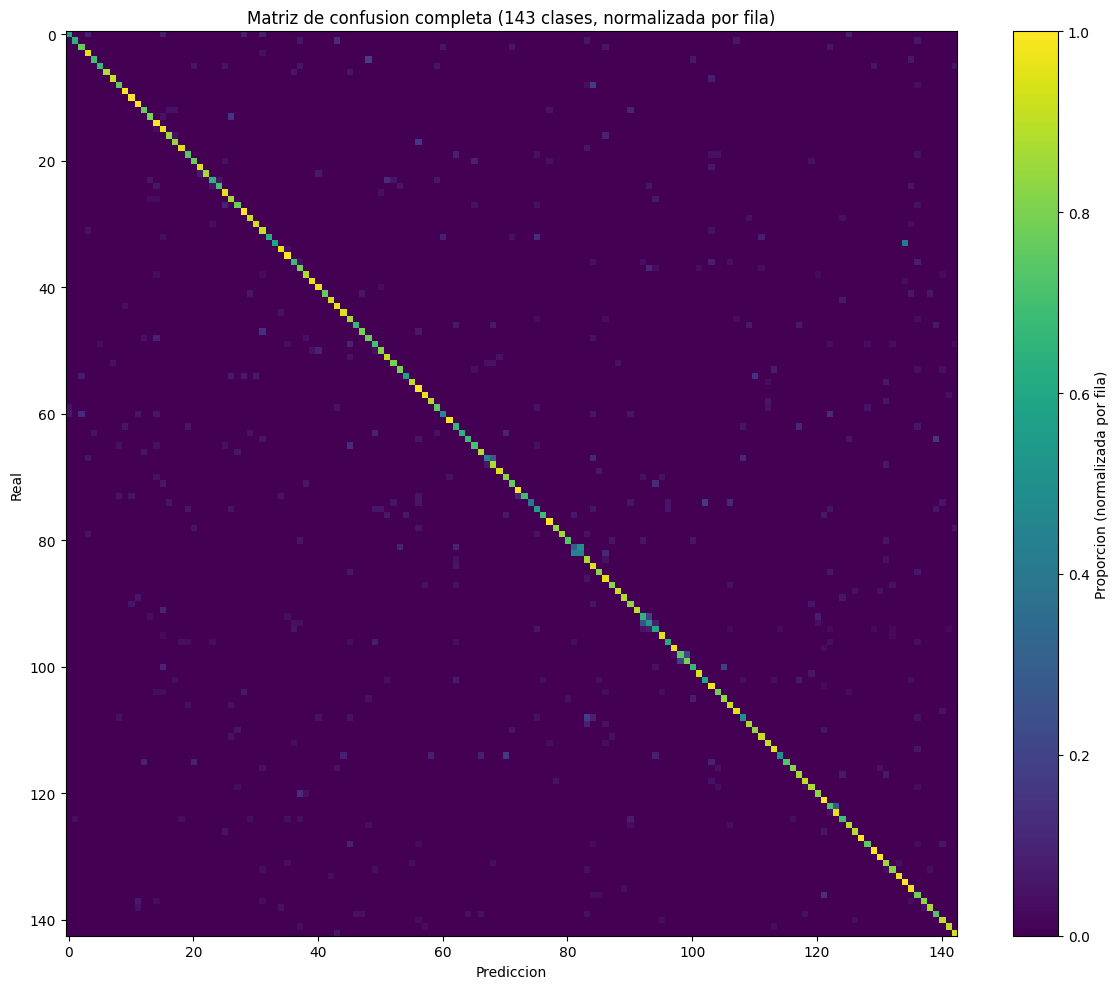

In [13]:
# 13. Matriz de confusion
cm = confusion_matrix(y_true, y_pred)
print('Shape de la matriz de confusion:', cm.shape)

# (a) Top 10 clases con mas errores (falsos negativos)
errors_per_class = cm.sum(axis=1) - np.diag(cm)
top_confused = np.argsort(errors_per_class)[-10:][::-1]
print('\nTop 10 Pokemon que mas se confunden:')
for idx in top_confused:
    print(f'  {class_labels[idx]}: {errors_per_class[idx]} errores de {cm[idx].sum()} muestras')

# (b) Pares (real -> predicho) mas confundidos, fuera de la diagonal
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
flat_order = np.argsort(cm_off, axis=None)[::-1]
print('\nTop 15 confusiones (real -> predicho):')
shown = 0
for flat in flat_order:
    i, j = np.unravel_index(flat, cm_off.shape)
    if cm_off[i, j] == 0 or shown >= 15:
        break
    print(f'  {class_labels[i]:<14} -> {class_labels[j]:<14} {cm_off[i, j]} veces')
    shown += 1

# (c) Matriz de confusion COMPLETA (143x143) normalizada por fila, como imagen
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, cmap='viridis', aspect='auto')
plt.colorbar(label='Proporcion (normalizada por fila)')
plt.title('Matriz de confusion completa (143 clases, normalizada por fila)')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# 14. Guardado del modelo final en formato .h5

model.save('pokemon_cnn_final.h5')
print('Modelo guardado en pokemon_cnn_final.h5')

# Verificamos que se puede cargar
from tensorflow.keras.models import load_model
loaded_model = load_model('pokemon_cnn_final.h5')
print('Modelo cargado correctamente. Capas:', len(loaded_model.layers))

Modelo guardado en pokemon_cnn_final.h5


Modelo cargado correctamente. Capas: 7


Imagen: /root/.cache/kagglehub/datasets/mikoajkolman/pokemon-images-first-generation17000-files/versions/1/pokemon/Weepinbell/5a1da738e21f429ea745697f1c2f08f9.jpg
  Weepinbell: 99.98%
  Weedle: 0.02%
  Kakuna: 0.00%


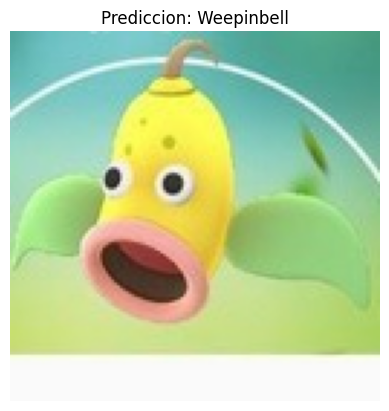

In [15]:
# 15. Prueba: prediccion sobre una imagen individual
# Demostracion de uso del modelo entrenado.

def predict_pokemon(img_path, model, class_labels, img_size=128):
    img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
    arr = np.array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    top3 = np.argsort(probs)[-3:][::-1]
    print(f'Imagen: {img_path}')
    for idx in top3:
        print(f'  {class_labels[idx]}: {probs[idx]*100:.2f}%')
    plt.imshow(img)
    plt.title(f'Prediccion: {class_labels[top3[0]]}')
    plt.axis('off')
    plt.show()

# Prueba con una imagen aleatoria del dataset
sample_class = random.choice(class_names)
sample_folder = os.path.join(DATA_DIR, sample_class)
sample_imgs = [f for f in os.listdir(sample_folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]
sample_path = os.path.join(sample_folder, random.choice(sample_imgs))
predict_pokemon(sample_path, model, class_labels)

In [16]:
# MODELO 2 - EfficientNetV2-S (mejora sobre el Modelo 1)
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effv2_preprocess

IMG_SIZE_2 = 224
BATCH_SIZE_2 = 32

train_datagen_2 = ImageDataGenerator(
    preprocessing_function=effv2_preprocess,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=10,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    validation_split=0.2
)
val_datagen_2 = ImageDataGenerator(
    preprocessing_function=effv2_preprocess,
    validation_split=0.2
)

train_gen_2 = train_datagen_2.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE_2, IMG_SIZE_2), batch_size=BATCH_SIZE_2,
    class_mode='categorical', subset='training', seed=42
)
val_gen_2 = val_datagen_2.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE_2, IMG_SIZE_2), batch_size=BATCH_SIZE_2,
    class_mode='categorical', subset='validation', seed=42, shuffle=False
)

base_model_2 = EfficientNetV2S(
    input_shape=(IMG_SIZE_2, IMG_SIZE_2, 3), include_top=False, weights='imagenet'
)
base_model_2.trainable = False

inputs_2 = tf.keras.Input(shape=(IMG_SIZE_2, IMG_SIZE_2, 3))
x = base_model_2(inputs_2, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
outputs_2 = Dense(NUM_CLASSES, activation='softmax')(x)

model_2 = Model(inputs_2, outputs_2)
loss_2 = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
model_2.compile(optimizer=Adam(learning_rate=1e-3), loss=loss_2, metrics=['accuracy'])
model_2.summary()

Found 13246 images belonging to 143 classes.
Found 3239 images belonging to 143 classes.
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 143)            │        36,751 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,696,047 (78.95 MB)

 Trainable params: 364,687 (1.39 MB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [17]:
# Entrenamiento Modelo 2 (fase 1 + fine-tuning) y evaluacion del mejor checkpoint
from tensorflow.keras.models import load_model

def callbacks_2(threshold=None):
    return [
        ModelCheckpoint('pokemon_effv2s_best.h5', monitor='val_accuracy',
                        save_best_only=True, initial_value_threshold=threshold, verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ]

history_2 = model_2.fit(train_gen_2, validation_data=val_gen_2,
                        epochs=15, callbacks=callbacks_2(), verbose=1)
best_2 = max(history_2.history['val_accuracy'])

base_model_2.trainable = True
for layer in base_model_2.layers[:-60]:
    layer.trainable = False
model_2.compile(optimizer=Adam(learning_rate=1e-4), loss=loss_2, metrics=['accuracy'])

history_2_ft = model_2.fit(train_gen_2, validation_data=val_gen_2,
                           epochs=12, callbacks=callbacks_2(threshold=best_2), verbose=1)

best_model_2 = load_model('pokemon_effv2s_best.h5')
val_gen_2.reset()
y_pred_2 = np.argmax(best_model_2.predict(val_gen_2, verbose=1), axis=1)
y_true_2 = val_gen_2.classes
acc_2 = np.mean(y_pred_2 == y_true_2)
print('Modelo 2 (EfficientNetV2-S) val_accuracy:', acc_2)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.1023 - loss: 4.5186
Epoch 1: val_accuracy improved from None to 0.70238, saving model to pokemon_effv2s_best.h5



Epoch 1: finished saving model to pokemon_effv2s_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 419s 883ms/step - accuracy: 0.1957 - loss: 3.9783 - val_accuracy: 0.7024 - val_loss: 2.1478 - learning_rate: 0.0010
Epoch 2/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.4277 - loss: 2.9048
Epoch 2: val_accuracy improved from 0.70238 to 0.80086, saving model to pokemon_effv2s_best.h5



Epoch 2: finished saving model to pokemon_effv2s_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 315s 761ms/step - accuracy: 0.4524 - loss: 2.8007 - val_accuracy: 0.8009 - val_loss: 1.7449 - learning_rate: 0.0010
Epoch 3/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.5241 - loss: 2.5567
Epoch 3: val_accuracy improved from 0.80086 to 0.83791, saving model to pokemon_effv2s_best.h5


...


Epoch 8: finished saving model to pokemon_effv2s_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 315s 761ms/step - accuracy: 0.8954 - loss: 1.4128 - val_accuracy: 0.9528 - val_loss: 1.2034 - learning_rate: 1.0000e-04
Epoch 9/12
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.9025 - loss: 1.3831
Epoch 9: val_accuracy improved from 0.95276 to 0.95554, saving model to pokemon_effv2s_best.h5



Epoch 9: finished saving model to pokemon_effv2s_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 315s 761ms/step - accuracy: 0.9022 - loss: 1.3841 - val_accuracy: 0.9555 - val_loss: 1.2038 - learning_rate: 1.0000e-04
Epoch 10/12
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.9148 - loss: 1.3601
Epoch 10: val_accuracy improved from 0.95554 to 0.95678, saving model to pokemon_effv2s_best.h5



Epoch 10: finished saving model to pokemon_effv2s_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 319s 770ms/step - accuracy: 0.9173 - loss: 1.3570 - val_accuracy: 0.9568 - val_loss: 1.1698 - learning_rate: 1.0000e-04
Epoch 11/12
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.9201 - loss: 1.3343
Epoch 11: val_accuracy did not improve from 0.95678
414/414 ━━━━━━━━━━━━━━━━━━━━ 309s 746ms/step - accuracy: 0.9199 - loss: 1.3373 - val_accuracy: 0.9562 - val_loss: 1.1724 - learning_rate: 1.0000e-04
Epoch 12/12
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.9259 - loss: 1.3190
Epoch 12: val_accuracy improved from 0.95678 to 0.95832, saving model to pokemon_effv2s_best.h5



Epoch 12: finished saving model to pokemon_effv2s_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 313s 754ms/step - accuracy: 0.9284 - loss: 1.3153 - val_accuracy: 0.9583 - val_loss: 1.1674 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 12.


102/102 ━━━━━━━━━━━━━━━━━━━━ 63s 521ms/step
Modelo 2 (EfficientNetV2-S) val_accuracy: 0.9583204692806422


                     modelo         backbone val_accuracy                  referencia
     Modelo 1 - MobileNetV2      MobileNetV2         0.81 Sandler et al. (2018), CVPR
Modelo 2 - EfficientNetV2-S EfficientNetV2-S       0.9583       Tan & Le (2021), ICML


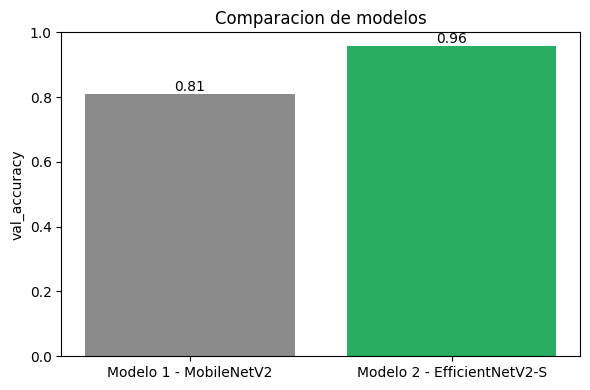

In [18]:
# ============================================================
# Comparacion de modelos
# ============================================================
#   Modelo 1 - MobileNetV2      -> Sandler et al. (2018), CVPR, arXiv:1801.04381
#   Modelo 2 - EfficientNetV2-S -> Tan & Le (2021),  ICML, arXiv:2104.00298

import pandas as pd
import matplotlib.pyplot as plt

resultados = {
    'Modelo 1 - MobileNetV2':      {'backbone': 'MobileNetV2',      'val_accuracy': 0.81,
                                    'referencia': 'Sandler et al. (2018), CVPR'},
    'Modelo 2 - EfficientNetV2-S': {'backbone': 'EfficientNetV2-S', 'val_accuracy': round(float(acc_2), 4),
                                    'referencia': 'Tan & Le (2021), ICML'},
}

tabla = pd.DataFrame(resultados).T.reset_index().rename(columns={'index': 'modelo'})
print(tabla[['modelo', 'backbone', 'val_accuracy', 'referencia']].to_string(index=False))

accs = [resultados[m]['val_accuracy'] for m in resultados]
plt.figure(figsize=(6, 4))
barras = plt.bar(list(resultados), accs, color=['#8a8a8a', '#27ae60'])
for b, a in zip(barras, accs):
    plt.text(b.get_x() + b.get_width() / 2, a + 0.01, f'{a:.2f}', ha='center')
plt.ylabel('val_accuracy')
plt.ylim(0, 1)
plt.title('Comparacion de modelos')
plt.tight_layout()
plt.show()